# Harmonic Oscillator

#### Hamilton equations   

$H(p,q)=T(p)+V(q)$. 

$\dot{q}=\frac{\partial H}{\partial p}$    
$\dot{p}=-\frac{\partial H}{\partial q}$  

#### The harmonic oscillator system
In the following example we are going to consider two particles under the harmonic oscilator potential. Physically, we can think of this system as two particles in the 3D space connected by a massless spring floting in an empty space. (There is NO other potentials that produces other forces, such as gravitational force or something, and there is no more than these 2 particles, so boundary conditions are not nedeed).   
<img src="..//img/24.Jan.26-21.23.00.excalidraw.png" width="500" height="340">

##### The Kinetic Energy
The kinetic energy $T(p)$ encompasses the energy caused by the movement of the particles, that is captured by the coordinate $p$.  
Because $p=mv$ and the velocity is different of 0 just if there is a change in the position of the particles.
$$T(p)=\frac{|p_1|^2}{2m_1}+\frac{|p_2|^2}{2m_2}$$
##### The Potential energy
The potential energy $V(r)$ is related to the energy that can be stored by the system, in this example, the only thing that can change the state of this energy is the displacement of the particles, and there is a lenght given $r_{eq}$ set by the potential itself that corresponds to the 'natural state', if the displacement between the particles is equal to this, the potential is 0, which means nothing happens to the system (equilibrium). $k$ is a constant of equilibrium.
$$V(q)=\frac{k}{2}(|q_1-q_2| - r_{eq})^2$$



##### From Hamiltonian to Forces (The Gradient)
To solve the system numerically, we need the "Change in Momentum" $(\dot{p})$, which Hamilton’s equations define as the negative gradient of the potential: $f=−\nabla_{q} V(q)$ 
This is a great way to structure your notebook. By building a "Unit Test" for your physics engine, you ensure the foundation is solid before adding the complexity of water molecules.

**The Force on Particle 1 ($\vec{f}_1$):**
Using the chain rule, we find the force acting on the first particle:


$$\vec{f}_1 = -k (|q_1 - q_2| - r_{eq}) \frac{q_1 - q_2}{|q_1 - q_2|}$$

**The Force on Particle 2 ($\vec{f}_2$):**
By Newton’s Third Law (or by taking the gradient with respect to $q_2$):


$$\vec{f}_2 = -\vec{f}_1$$

## The numerical integrator Velocity Verlet

**Velocity Verlet** is the standard choice in Molecular Dynamics because it is "Symplectic" (it preserves the geometry of Phase Space) and leads to excellent energy conservation.

**The Algorithm (for each time step $\Delta t$):**

1. **Update Position:** $q(t + \Delta t) = q(t) + \frac{p(t)}{m}\Delta t + \frac{f(t)}{2m}\Delta t^2$
2. **Half-step Momentum:** $p(t + \frac{\Delta t}{2}) = p(t) + \frac{1}{2}f(t)\Delta t$
3. **Calculate New Forces:** Evaluate $f(t + \Delta t)$ using the new positions $q(t + \Delta t)$.
4. **Full-step Momentum:** $p(t + \Delta t) = p(t + \frac{\Delta t}{2}) + \frac{1}{2}f(t + \Delta t)\Delta t$


In [10]:
import numpy as np

# velocity-verlet integrator that works for arbitrary particle counts and potentials

def velocity_verlet(q, p, masses, force_func, dt, num_steps):
    """Integrate Hamiltonian mechanics using velocity Verlet.

    Parameters
    ----------
    q : ndarray, shape (N, D)
        Initial positions of N particles in D dimensions.
    p : ndarray, shape (N, D)
        Initial momenta of the particles.
    masses : ndarray, shape (N,)
        Mass of each particle.
    force_func : callable
        Function `f(q)` returning forces array of shape (N, D).
    dt : float
        Time step.
    num_steps : int
        Number of steps to integrate.

    Returns
    -------
    traj_q : ndarray, shape (num_steps+1, N, D)
        Positions at each time step.
    traj_p : ndarray, shape (num_steps+1, N, D)
        Momenta at each time step.
    """
    q = np.array(q, dtype=float)
    p = np.array(p, dtype=float)
    masses = np.array(masses, dtype=float)
    n, dim = q.shape

    traj_q = np.zeros((num_steps + 1, n, dim))
    traj_p = np.zeros_like(traj_q)

    traj_q[0] = q
    traj_p[0] = p

    # precompute mass column for vectorized operations
    mcol = masses[:, None]

    f = force_func(q)
    for i in range(num_steps):
        # 1. update positions
        q = q + (p / mcol) * dt + 0.5 * (f / mcol) * dt ** 2
        # 2. half-step momentum
        p_half = p + 0.5 * f * dt
        # 3. compute new forces
        f = force_func(q)
        # 4. full-step momentum
        p = p_half + 0.5 * f * dt

        traj_q[i + 1] = q
        traj_p[i + 1] = p

    return traj_q, traj_p

## Kinetic Energy

In [11]:
def kinetic_energy(p, masses):
    """Return total kinetic energy of the system."""
    masses = np.array(masses, dtype=float)
    return np.sum(np.sum(p ** 2 / (2 * masses[:, None]), axis=1))


## Potential Energy: Harmonic oscillator

In [12]:
# potential energy function for the harmonic spring for tracking energy conservation
def harmonic_potential(positions, k=1.0, r0=1.0):
    q1, q2 = positions[0], positions[1]
    r = np.linalg.norm(q1 - q2)
    return 0.5 * k * (r - r0) ** 2


## Total Energy

In [13]:
def total_energy(q, p, masses, potential_func):
    """Total energy = kinetic + potential."""
    return kinetic_energy(p, masses) + potential_func(q)

# Basic test: integrating with zero forces should keep q constant and p constant
if False:
    dummy_force = lambda pos: np.zeros_like(pos)
    q0 = np.array([[0.0, 0.0, 0.0], [1.0, 0.0, 0.0]])
    p0 = np.array([[0.0, 0.0, 0.0], [0.0, 0.0, 0.0]])
    masses_test = np.array([1.0, 1.0])
    traj_q, traj_p = velocity_verlet(q0, p0, masses_test, dummy_force, 0.1, 10)
    assert np.allclose(traj_q, q0)
    assert np.allclose(traj_p, p0)

## Force derivated by the potential

In [14]:
# now define the specific potential/force for the 2-particle harmonic spring

def harmonic_force(positions, k=1.0, r0=1.0):
    """Compute forces for two particles connected by a harmonic spring.

    Parameters
    ----------
    positions : ndarray, shape (2, D)
        The positions of the two particles.
    k : float
        Spring constant.
    r0 : float
        Equilibrium length.

    Returns
    -------
    forces : ndarray, shape (2, D)
        Force on each particle (f1, f2 = -f1).
    """
    q1, q2 = positions[0], positions[1]
    diff = q1 - q2
    r = np.linalg.norm(diff)
    if r == 0:
        return np.zeros_like(positions)
    # magnitude of force
    mag = -k * (r - r0)
    # direction from 1 to 2
    direction = diff / r
    f1 = mag * direction
    f2 = -f1
    return np.vstack([f1, f2])

## Initial conditions and parameters of Harmonic oscillator

In [64]:
# Parameters for the harmonic oscillator system
m1 = 1.0  # mass of particle 1
m2 = 1.0  # mass of particle 2
k = 1.0   # spring constant
r0 = 0.5   # equilibrium length of the spring   

# Initial positions and momenta
q1 = np.array([0.0, 0.0, 0.0])
q2 = np.array([1.0, 0.0, 0.0])
p1 = np.array([0.0, 1.0, 1.0])
p2 = np.array([0.0, 1.0, 1.0])

In [110]:
# Time step for the simulation
dt = 0.01
# Total simulation time
total_time = 20.0
# Number of steps in the simulation
num_steps = int(total_time / dt)

In [111]:
# create callables with our chosen parameters
spring_force = lambda pos: harmonic_force(pos, k=k, r0=r0)
spring_pot = lambda pos: harmonic_potential(pos, k=k, r0=r0)

# initial condition arrays
masses = np.array([m1, m2])
q_init = np.vstack([q1, q2])
p_init = np.vstack([p1, p2])

# integrate
traj_q, traj_p = velocity_verlet(q_init, p_init, masses, spring_force, dt, num_steps)

# compute energy along trajectory
en = np.array([total_energy(traj_q[i], traj_p[i], masses, spring_pot) for i in range(len(traj_q))])

# quick diagnostics
print("initial energy", en[0])
print("final energy", en[-1])
print("max energy drift", np.max(np.abs(en - en[0])))
print("Time step size:", dt, "Time interval:", total_time, "Number of steps:", num_steps)
# print parameters for reproducibility
if False:
    print(f"Parameters: m1={m1}, m2={m2}, k={k}, r0={r0}")
    print(f"Initial conditions: q1={q1}, q2={q2}, p1={p1}, p2={p2}")


initial energy 2.125
final energy 2.124999999353202
max energy drift 6.249994351392729e-06
Time step size: 0.01 Time interval: 20.0 Number of steps: 2000


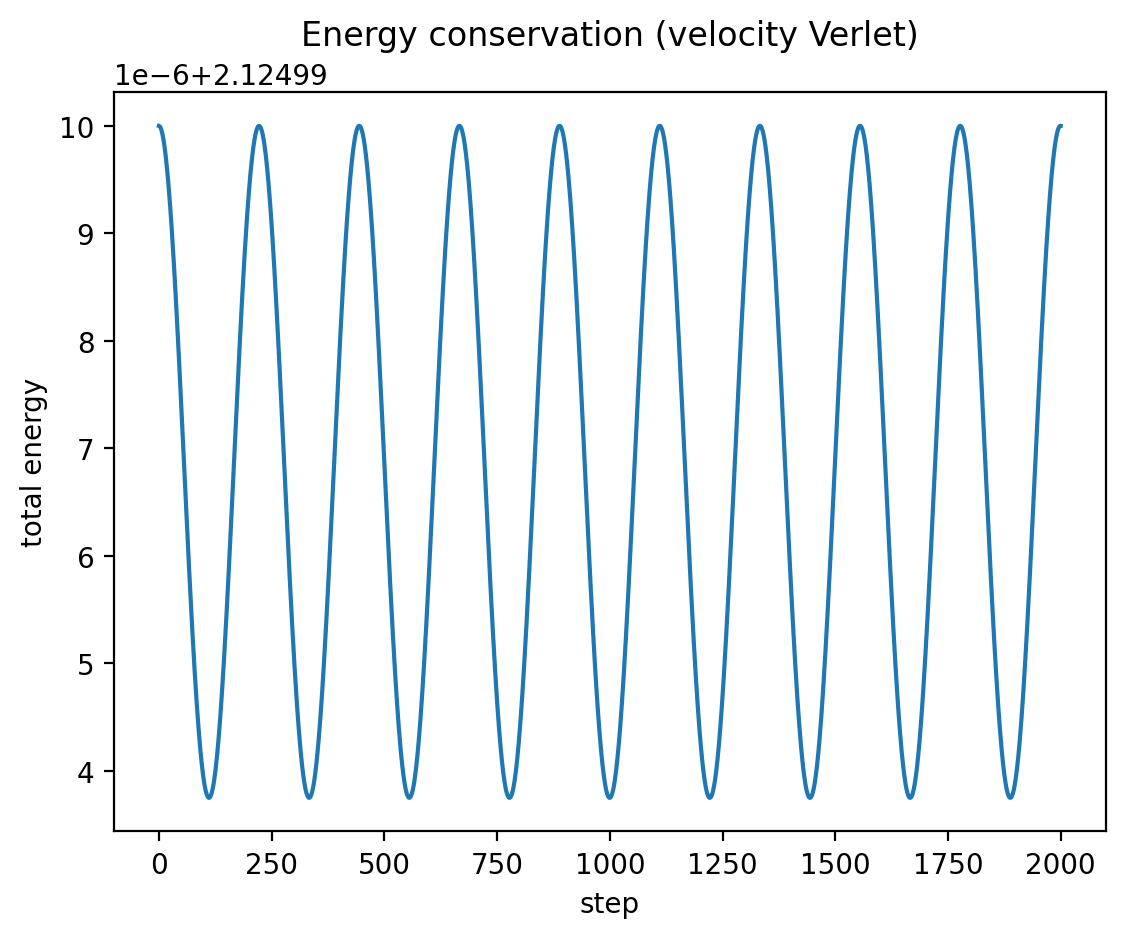

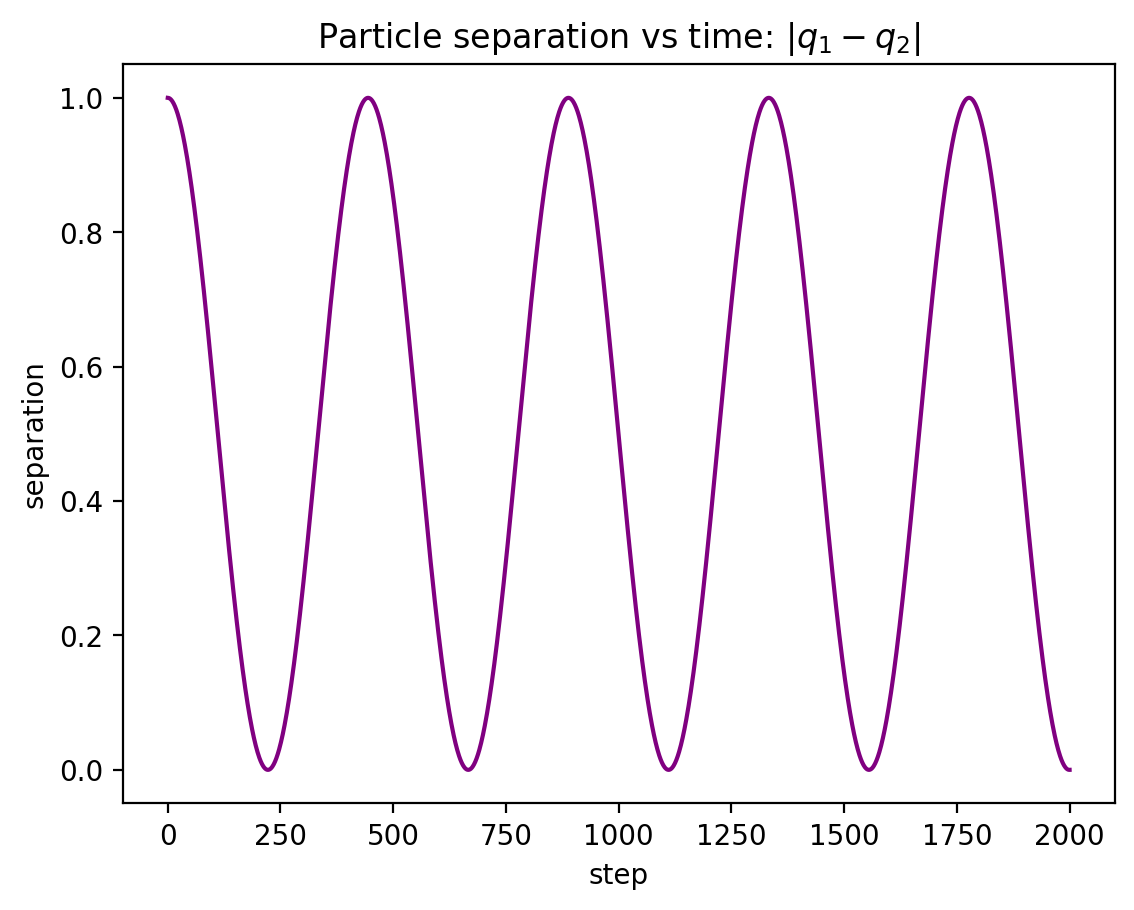

In [112]:
# you could visualize, e.g., the distance between particles or energies
import matplotlib.pyplot as plt
%config InlineBackend.figure_format = 'retina'



plt.figure()
plt.plot(en)
plt.xlabel('step')
plt.ylabel('total energy')
plt.title('Energy conservation (velocity Verlet)')
plt.show()

plt.figure()
dist = np.linalg.norm(traj_q[:,0] - traj_q[:,1], axis=1)
plt.plot(dist, color='purple')
plt.xlabel('step')
plt.ylabel('separation')
plt.title('Particle separation vs time: $|q_1 - q_2|$')
plt.show()

## Analytical solution

To prove the code works, we compare it to the exact solution. For a two-body oscillator, we define:

* **Reduced Mass:** $\mu = \frac{m_1 m_2}{m_1 + m_2}$
* **Angular Frequency:** $\omega = \sqrt{k/\mu}$

If we pull the particles apart and release them from rest at $t=0$, the distance $r(t) = |q_1 - q_2|$ evolves as:


$$r(t) = r_{eq} + (r_{initial} - r_{eq}) \cos(\omega t)$$


(Equation above don't consider the intial velocities)

In [ ]:
# Analytical solution for comparison
reduced_mass = (m1 * m2) / (m1 + m2)
omega = np.sqrt(k / reduced_mass)
t = np.linspace(0, total_time, num_steps + 1)

# 1. Calculate the initial relative distance vector and magnitude
r_vec_init = q_init[0] - q_init[1]
r_mag_init = np.linalg.norm(r_vec_init)

# 2. Calculate the initial relative velocity vector
# (Assumes you have v_init from p_init/mass)
v_rel_init = (p_init[0]/m1) - (p_init[1]/m2)

# 3. Project velocity onto the bond vector to get the radial speed (dr/dt)
# This is the dot product of relative velocity and the unit bond vector
v_radial_init = np.dot(v_rel_init, r_vec_init / r_mag_init)

# 4. Corrected Analytical Solution
A = r_mag_init - r0
B = v_radial_init / omega

analytical_dist = r0 + A * np.cos(omega * t) + B * np.sin(omega * t)

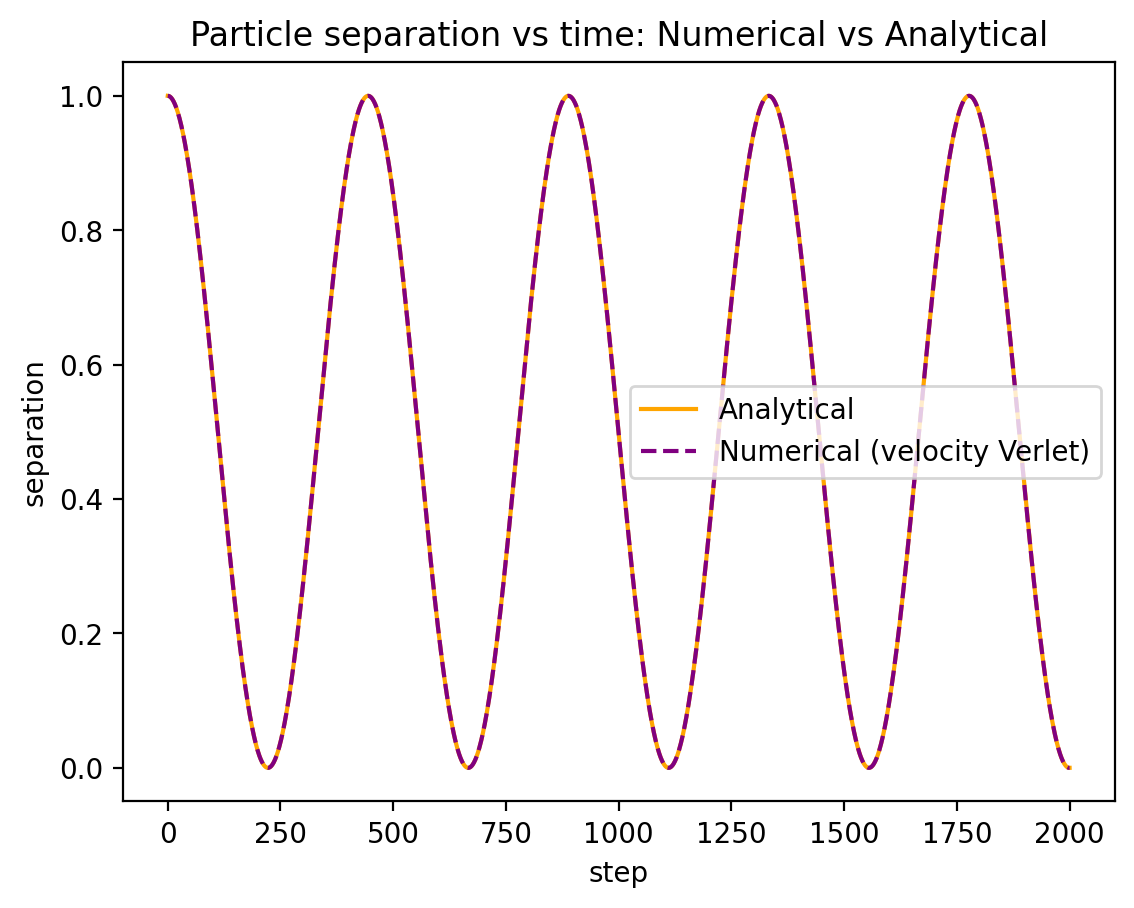

In [114]:
# Plot numerical vs analytical distance
plt.figure()
plt.plot(analytical_dist, label='Analytical', color='orange', linestyle='-')
plt.plot(dist, label='Numerical (velocity Verlet)', color='purple', linestyle='--')
plt.xlabel('step')
plt.ylabel('separation')
plt.title('Particle separation vs time: Numerical vs Analytical')
plt.legend()
plt.show()  

To consider: For this specific validation comparison, we should ensure the initial velocities $p_1$ and $p_2$ are radial, otherwise the system could rotate (the analytical solution is not like this anymore).

---

## Validation

1. **Energy Conservation:** Plot the Total Energy ($H = T + V$) over time. In a correct MD simulation, the energy should fluctuate slightly but have **zero drift** over long periods.
2. **Trajectory Overlay:** Plot the numerical distance $r_{num}(t)$ on top of the analytical $r_{analytical}(t)$. They should overlap perfectly.
3. **Time-Step Sensitivity:** Show what happens if $\Delta t$ is too large (the system "explodes" or energy drifts). This teaches the team the importance of choosing a proper time step for the water project.